# Midterm Project

### Introduction

This document will analyze data sampled on a quarterly basis from 2010 to 2023 of the seasonally adjusted annual rate (SAAR) of real GDP growth in the United States from the U.S. Bureau of Economic Analysis (BEA). The techniques employed will be cubic spline interpolation, polynomial fitting, and linear least squares fitting. Cubic spline interpolation distinctly passes through every point using piecewise functions that are smooth and continuous. In comparison, both polynomial and linear least squares fitting solve for one single function that is used to approximate the whole dataset by finding the function that minimizes error to the greatest degree. The key difference between these two methods is that a linear fit specifically uses a 1st degree polynomial, while a polynomial fit is a more general term defining a fit using any nth degree polynomial.

### Data

In [30]:
import numpy as np
x=np.array([1,5,9,13,17,19,22,25,27,28,29,33,37,41,42,43,45,49,54,56])
y=np.array([1.7,.1,2.3,2.7,1.7,5.0,3.0,1.5,3.5,1.8,1.3,2.5,3.1,-5.1,-28.1,33.8,6.3,-1.6,2.4,3.3])

# Cubic Spline Interpolation

### Methodology
My method for constructing a cubic spline where n is the number of data points and the cubic polynomial for each interval [xi,xi+1] is Si(x)=ai+bi(x-xi)+ci(x-xi)+di(x-xi) involves calculating the ci coefficient for each Si(x) based on the condition ai=yi and the continuity of Si(xi+1)=Si+1(xi+1) and their first and second derivatives (the second derivatives at the boundaries are set equal to zero according to the definition of a natural spline). The equations implied by these conditions allow for the construction of an (n-2)x(n-2) tridiagonal matrix with n-2 unknowns ci. The calculated ci are then plugged back into the original equations to solve for the other coefficients for each interval. The splines are then evaluated using these coeffients to create the cubic spline interpolation.

Source: https://www.youtube.com/watch?v=zhSoqOOD1pA&list=LL&index=1&t=9s

### Functions

In [2]:
import numpy as np
def x_eval(x,y,C,i): #Compute coefficients for Si(x) using Ci
    h=np.diff(x) #intervals
    Coeff=np.zeros(4) #initialize
    #Compute coefficients
    Coeff[2]=C[i]
    Coeff[0]=y[i]
    Coeff[1]=1/h[i]*(y[i+1]-y[i])-h[i]/3*(2*C[i]+C[i+1])
    Coeff[3]=(C[i+1]-C[i])/(3*h[i])
    return Coeff
def spline(t,x,Coeff,i): #Evaluate Spline
    y=Coeff[0]+Coeff[1]*(t-x[i])+Coeff[2]*((t-x[i])**2)+Coeff[3]*((t-x[i])**3)
    return y
def setup_tridiagonal_matrix(x, y): #Setup Tridiagonal Matrix
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 3) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 3) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1,n-2):
        A[i - 1] = h[i] # Subdiagonal
        C[i - 1] = h[i] # Superdiagonal
    for i in range(1, n - 1):
        B[i - 1] = 2*(h[i-1]+h[i]) # Main diagonal
        D[i - 1] = 3/h[i]*(y[i+1]-y[i])-3/h[i-1]*(y[i]-y[i-1]) #rhs
    return A, B, C, D
def thomas_algorithm(a, b, c, d): #Thomas Algoritm
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

#### Call Tridiagonal Matrix Function

In [3]:
n=x.size-1
# Set up the tridiagonal matrix for the cubic spline
A, B, C1, D = setup_tridiagonal_matrix(x, y)

#### Call Thomas Algorithm Function

In [4]:
C=np.zeros(x.size) #initailize
C[1:x.size-1] = thomas_algorithm(A, B, C1, D) 
print("C Coefficients:", C)

C Coefficients: [ 0.00000000e+00  1.97959927e-01 -7.93397063e-02 -2.18101101e-01
  6.89244112e-01 -8.49262469e-01  5.47121557e-02  7.97080513e-01
 -1.81747080e+00  1.21066377e+00  5.74815723e-01 -1.13970525e+00
  3.87150527e+00 -1.59963158e+01  8.16271373e+01 -5.58122334e+01
  1.31481316e+01 -2.70702806e+00  8.91795735e-01  0.00000000e+00]


#### Evaluate Spline on Each Interval

In [5]:
poly_eval=np.zeros(np.int64(x[-1]*100+1-(x[0]*100))) #Initialize
#Create array of X values to evaluate spline
poly_x=np.linspace(x[0],x[-1],np.int64(x[-1]*100+1-(x[0]*100))) 
#Evaluate the spline for each set of coefficients
for i in range (0,n):
    Coeff=x_eval(x,y,C,i)
    t=poly_x[np.int64(x[i]*100-(x[0]*100)):np.int64(x[i+1]*100+1)]
    poly_y=spline(t,x,Coeff,i)
    poly_eval[np.int64(x[i]*100-(x[0]*100)):np.int64(x[i+1]*100+1)]=poly_y  

#### Plot Splines

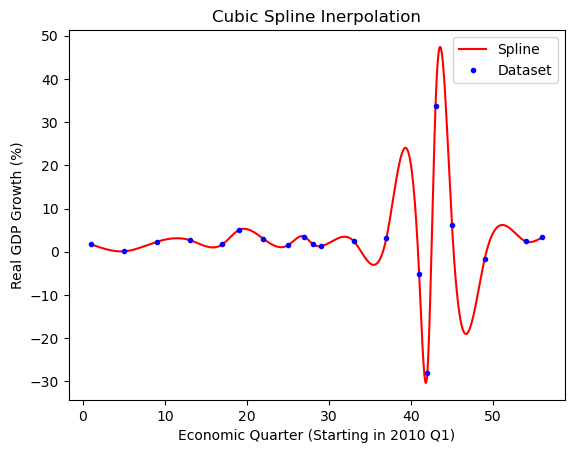

In [6]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(poly_x,poly_eval,'r',label="Spline")
plt.plot(x,y,'b.',label="Dataset")
plt.title("Cubic Spline Inerpolation")
plt.xlabel("Economic Quarter (Starting in 2010 Q1)")
plt.ylabel("Real GDP Growth (%)")
plt.legend()
plt.show()

#### Discussion

The interpolant appears visually smooth and reasonable. It is clearly seen that the continuity conditions were enforced, as the line passes through every point. It is also clear that the smoothness condition of continuity of the first and second dervatives has been enforced based on the lack of corners or sudden changes in concavity which would indicate discontinuous derivatives.

In the context of analyzing the predictive accuracy of a model the Runge phenomenon describes large oscillations between data points that may not reflect real trends in the data. This can be seen near outliers in the data in this cubic spline interpolation, where the line rises and falls sharply between data points in multiple instances. What more likely occurred in reality was a more steady decline or rise between data points which is poorly represented by sharp oscillations in the graph. This demonstrates a trade off between exact interpolation and numerical stability, as a line that must pass through every point can overfit to the data whereas a more stable approximation which responds less to outliers may miss an important trend if the outliers were important to the story of the dataset. I think that the preferable solution here would be to smooth out sections of the cubic spline where the oscillations are excessive, but in this case because the outliers are an important part of the dataset (COVID), it is important to interpolate through all points.

## Least Squares Polynomial Fitting

### Polyfit

In [7]:
def poly(x,y,n): 
    A=np.zeros((n+1,n+1)) #initialize vandermonde matrix
    rhs=np.zeros(n+1) #initialize right hand side
    for i in range(0,n+1): #Fill right hand side
        rhs[i]=np.sum(y*(x**i))
    for i in range(0,n+1): #fill vandermonde matrix
        for j in range(0,n+1):
            A[i,j]=np.sum((x**i)*(x**j))
    print(A)
    print(rhs)
    polyfit=np.linalg.solve(A,rhs) # solve system
    return polyfit
        

In [8]:
t=np.linspace(0,56,561)
polyfit=poly(x,y,4)
#evaluate polynomial over t
poly_eval1=polyfit[0]+polyfit[1]*t+polyfit[2]*t**2+polyfit[3]*t**3+polyfit[4]*t**4 

[[2.00000000e+01 5.95000000e+02 2.26190000e+04 9.58081000e+05
  4.33471670e+07]
 [5.95000000e+02 2.26190000e+04 9.58081000e+05 4.33471670e+07
  2.05025450e+09]
 [2.26190000e+04 9.58081000e+05 4.33471670e+07 2.05025450e+09
  1.00096849e+11]
 [9.58081000e+05 4.33471670e+07 2.05025450e+09 1.00096849e+11
  5.00374798e+12]
 [4.33471670e+07 2.05025450e+09 1.00096849e+11 5.00374798e+12
  2.54734755e+14]]
[4.12000000e+01 1.24880000e+03 4.79728000e+04 2.08989020e+06
 9.80120188e+07]


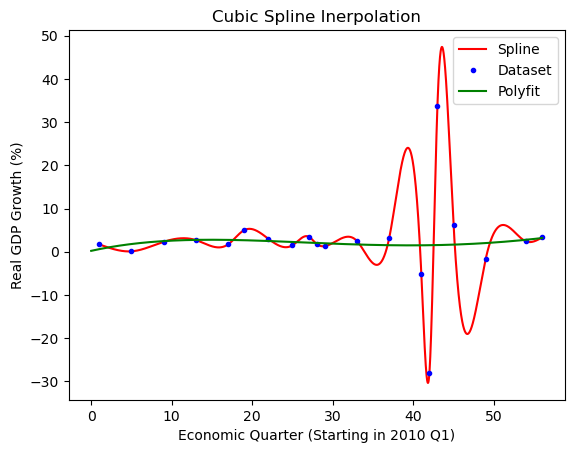

In [9]:
plt.figure()
plt.title("Least Squares Regression")
plt.plot(poly_x,poly_eval,'r',label="Spline")
plt.plot(x,y,'b.',label="Dataset")
plt.plot(t,poly_eval1,'g-',label="Polyfit")
plt.title("Cubic Spline Inerpolation")
plt.xlabel("Economic Quarter (Starting in 2010 Q1)")
plt.ylabel("Real GDP Growth (%)")
plt.legend()
plt.show()

In [10]:
# Mean Squared Error (MSE)
y_pred=np.zeros(20)
#Convert polynomial evaluation to a compatible size in order to evaluate against the dataset
for i in range (0,20):
    shell=(t<=(x[i]+.0001)) & (t>=(x[i]-.001))
    match=poly_eval1[shell]
    y_pred[i]=match
mse = np.mean((y - y_pred)**2)
print(f'Mean Squared Error: {mse:.4f}')

# R-squared value
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')


Mean Squared Error: 100.6298
R-squared: 0.0035


/tmp/ipykernel_13105/4082348563.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_pred[i]=match


#### Discussion

The overall trend is better captured by the least squares polynomial because it is less sensitive to noise, allowing for easier interpretation of the long term patterns in the data, whereas the cubic spline passes through every data point and therefore is more effective at reproducing short term trends in the data created by outliers. This tradeoff between approximation and interpolation means that while it may be more difficult to extract the long term implications of the data using a cubic spline, stories created by outliers are always accounted for. In contrast, the polynomial fit is better for approximating long term trends, but does not respond to outliers in a noticeable way. That said, an argument could be made for increasing the degree of this polynomial fit due to the very low R squared and very high MSE, which indicate that the line is barely better than the mean for predicting the dataset.

### Linear Function Code

In [11]:
def lstsq(X,Y):
    #Matrices built with partial derivatives of residual set equal to zero (minimize r^2)
    A=np.array([[Y.size,np.sum(X)],[np.sum(X),np.sum(X**2)]]) 
    rhs=np.array([np.sum(Y),np.sum(Y*X)])
    b,m=np.linalg.solve(A,rhs)
    return b,m

In [12]:
#Create datasets excluding COVID
x1=np.zeros(16)
x1[0:14]=x[0:14]
x1[14:16]=x[18:20]
y1=np.zeros(16)
y1[0:14]=y[0:14]
y1[14:18]=y[18:20]
#Call and evaluate function
b,m=lstsq(x1,y1)
t=np.linspace(0,56,561)
y_lin_lstsq=m*t+b
print("Slope=", (y_lin_lstsq[-1]-y_lin_lstsq[0])/(t[-1]-t[0]))

Slope= -0.008049946865037183


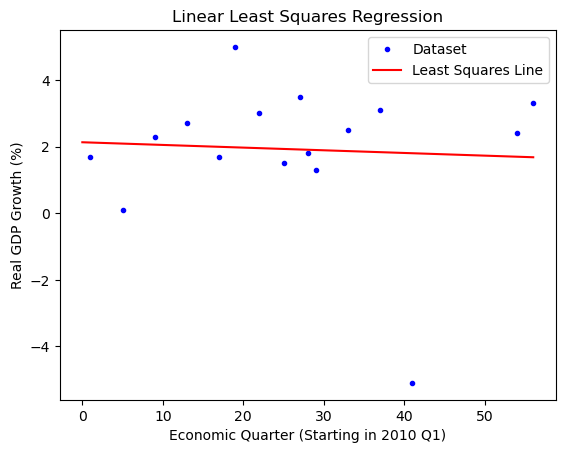

In [13]:
plt.figure()
plt.title("Linear Least Squares Regression")
plt.xlabel("Economic Quarter (Starting in 2010 Q1)")
plt.ylabel("Real GDP Growth (%)")
plt.plot(x1,y1, 'b.',label="Dataset")
plt.plot(t,y_lin_lstsq,'r',label="Least Squares Line")
plt.legend()
plt.show()

In [14]:
# Mean Squared Error (MSE)
y_pred=np.zeros(16)
#Convert polynomial evaluation to a compatible size in order to evaluate against the dataset
for i in range (0,16):
    shell=(t<=(x[i]+.0001)) & (t>=(x[i]-.001))
    match=y_lin_lstsq[shell]
    y_pred[i]=match
mse = np.mean((y1 - y_pred)**2)
print(f'Mean Squared Error: {mse:.4f}')

# R-squared value
ss_total = np.sum((y1 - np.mean(y))**2)
ss_res = np.sum((y1 - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

Mean Squared Error: 4.3958
R-squared: 0.0139


/tmp/ipykernel_13105/3264967604.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_pred[i]=match


#### Discussion

A linear trend does not make sense for economic data. Firstly, it assumes the absence of exponential effects in the economy which is a false assumption. It is fully possible for factors to cause exponential growth or decay of the GDP growth rate. Secondly, by approximating the whole dataset with one line, it assumes a constant trend throughout all of the data which relies on the assumption that the rate of change of the percentage of economic growth is either always trending upwards or always downwards which does not align with reality. For these reasons it is more accurate to approximate economic data using a piecewise spline or polynomial approximation that takes into account both exponential effects and variability in the trend of the data.



## Method Choice and Justification

I would choose the cubic spline interpolation in order to estimate GDP growth between quarters due to several key advantages. One advantage is that a cubic spline is a piecewise function which allows it to account for different trends in different part of the data without overfitting to one part of the data in particular. This mitigates some of the downsides of an overfitted polynomial which may oscillate far more excessively between data points. Another advantage is that the cubic spline accounts for outliers more effectively, passing through every point and thus treating the outliers as part of the story rather than noise. This method's effectiveness is evident by its ability to account for the COVID-19 pandemic numbers compared to the polyfit. The polynomial fit completely failed to show the effect of the COVID 19 pandemic, its inability to account for these data points demonstrated by the R squared of 0.0035 and MSE of 100.6298. For context, an R squared of one means that the line was a perfect fit, while an R squared of zero means the prediction was no better than the mean at predicting the data, and the MSE indicates the sum of the squared residuals. These numbers demonstrate the polyfit's inability to predict the data much better than the mean, making it a poor tool for predicting GDP between quarters. While the polynomial fit may preserve the overall trend due to its stability, the spline is a far better tool for estimating GDP between quarters especially in the case of outliers.

## Big O Analysis

### Cubic Spline

In [15]:
import time as time
print("started")
t_run=np.zeros(996)
#Evaluate cubic spline using different numbers of data points
for i in range (5,1001):
    x=np.arange(0,i)
    n=x.size-1
    y=np.arange(0,i)
    t1=time.perf_counter()
    # Set up the tridiagonal matrix for the cubic spline
    A, B, C1, D = setup_tridiagonal_matrix(x, y)
    C=np.zeros(x.size)
    C[1:x.size-1] = thomas_algorithm(A, B, C1, D) 
    poly_eval=np.zeros(np.int64(x[-1]*100+1-(x[0]*100)))
    poly_x=np.linspace(x[0],x[-1],np.int64(x[-1]*100+1-(x[0]*100)))
    for i in range (0,n):
        Coeff=x_eval(x,y,C,i)
        t=poly_x[np.int64(x[i]*100-(x[0]*100)):np.int64(x[i+1]*100+1)]
        poly_y=spline(t,x,Coeff,i)
        poly_eval[np.int64(x[i]*100-(x[0]*100)):np.int64(x[i+1]*100+1)]=poly_y  
    t2=time.perf_counter()
    t_run[i-5]=t2-t1 #Record time for each cubic spline evaluation
n=np.arange(5,1001)

started


#### Plot

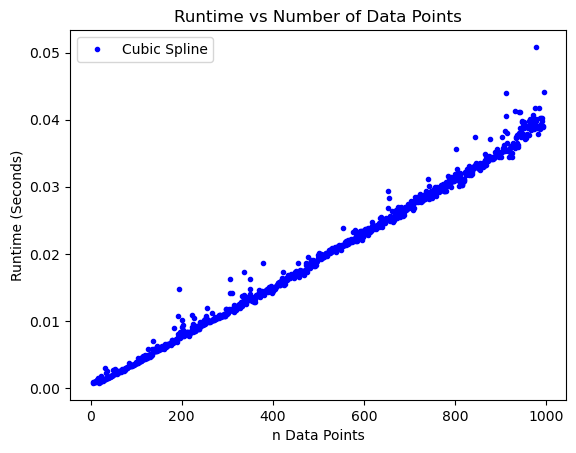

In [16]:
plt.figure()
plt.plot(n[0:-5],t_run[0:-5],'b.', label="Cubic Spline")
plt.title("Runtime vs Number of Data Points")
plt.legend()
plt.ylabel("Runtime (Seconds)")
plt.xlabel("n Data Points")
plt.show()

### Polynomial Fit

In [17]:
def poly(x,y,n): 
    A=np.zeros((n+1,n+1)) #initialize vandermonde matrix
    rhs=np.zeros(n+1) #initialize right hand side
    for i in range(0,n+1): #Fill right hand side
        rhs[i]=np.sum(y*(x**i))
    for i in range(0,n+1): #fill vandermonde matrix
        for j in range(0,n+1):
            A[i,j]=np.sum((x**i)*(x**j))
    polyfit=np.linalg.solve(A,rhs) # solve system
    return polyfit

In [18]:
t_run=np.zeros(9996)
#Evaluate polyfit using different numbers of data points
for i in range (5,10001):
    x=np.arange(0,i)
    y=np.arange(0,i)
    t1=time.perf_counter()
    t=np.linspace(0,56,561)
    polyfit=poly(x,y,4)
    poly_eval1=polyfit[0]+polyfit[1]*t+polyfit[2]*t**2+polyfit[3]*t**3+polyfit[4]*t**4 #evaluate polynomial over t
    t2=time.perf_counter()
    t_run[i-5]=t2-t1 #Record time for each evaluation
n=np.arange(5,10001)


#### Plot

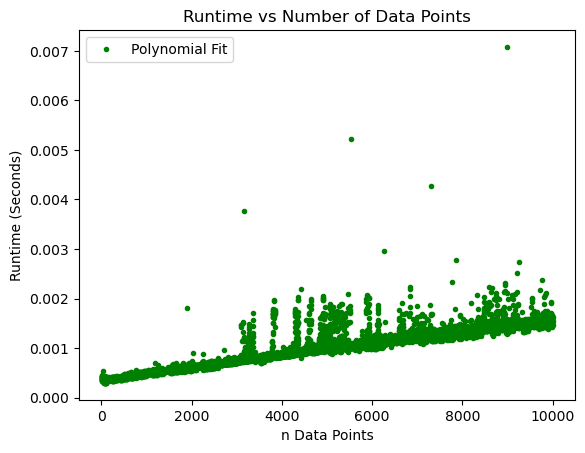

In [19]:
plt.figure()
plt.plot(n[5:],t_run[5:],'g.', label="Polynomial Fit")
plt.title("Runtime vs Number of Data Points")
plt.legend()
plt.ylabel("Runtime (Seconds)")
plt.xlabel("n Data Points")
plt.show()

### Linear Least Squares

In [23]:
def lstsq(X,Y):
    A=np.array([[Y.size,np.sum(X)],[np.sum(X),np.sum(X**2)]])
    rhs=np.array([np.sum(Y),np.sum(Y*X)])
    b,m=np.linalg.solve(A,rhs)
    return b,m

In [28]:
t_run=np.zeros(9996)
#Evaluate lstsq using different numbers of data points
for i in range (5,10001):
    x=np.arange(0,i)
    y=np.arange(0,i)
    t1=time.perf_counter()
    b,m=lstsq(x,y)
    #lstsq function
    t=np.linspace(0,10,40)
    y=m*t+b
    t2=time.perf_counter()
    t_run[i-5]=t2-t1 #Record time for each evaluation
n=np.arange(5,10001)

#### Plot

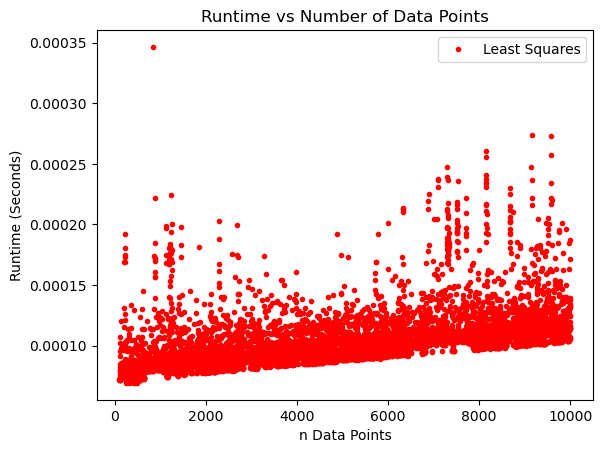

In [29]:
plt.figure()
plt.plot(n[100:],t_run[100:],'r.', label="Least Squares")
plt.title("Runtime vs Number of Data Points")
plt.legend()
plt.ylabel("Runtime (Seconds)")
plt.xlabel("n Data Points")
plt.show()

### Analysis

Big O notation denotes the rate at which the computational expense of a program grows with respect to the size of the data processed. For example, if the runtime of a program grows proportionally to n^3, then the big O notation would be O(n^3). In the case of the cubic spline, polynomial fit, and linear least squares the runtime appears to increase linearly with the number of data points processed, so I would estimate they are O(n) programs. Although they are all linear, the slope of the cubic spline's increase in runtime is the greatest, followed by the polynomial fit, and finally the linear least squares. This must be taken into consideration, however, given the low volume of GDP data that needs to be analyzed (only 4 data points per year) I would reaffirm my choice of the cubic spline because it should easily be able to handle a resonable volume of GDP data.

## Conclusion

Through the analysis of this data by the three techniques above, it is clear that the cubic spline was the superior method for the purpose of interpolation between points in the data. In contrast, the polynomial fit better represents the overall trend of the data so long as it is not overly fitted to the dataset. The key limitation of interpolation is that it is sensitive to noise which can distort the picture of the overall trend if the oulier is truly noise that is unreflective of any relevant phenomenon. On the other hand, overly stable approximations that analyze trends without responding significantly to noise can fail to portray outliers that are of importance to the story of the dataset. 